#Imports


In [ ]:
# All imports for model here
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, InceptionV3
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, Adadelta, RMSprop
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Testing Model Using Dataset Made By Me


In [ ]:



train_dir_old = '/content/drive/MyDrive/ASL Dataset/split/trainsplit'
val_dir_old = '/content/drive/MyDrive/ASL Dataset/split/validation'

test_dir_new = '/content/drive/MyDrive/ASL Dataset CAMASL'

image_size = (224, 224)
batch_size = 16

# Define ImageDataGenerators for the training, validation, and testing data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    fill_mode='nearest'      # Fill in missing pixels
)

new_dataset_datagen = ImageDataGenerator(rescale=1./255)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir_old,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Validation data generator
validation_generator = train_datagen.flow_from_directory(
    val_dir_old,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Test data generator
test_generator = new_dataset_datagen.flow_from_directory(
    test_dir_new,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Handling class imbalance
y_true = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true),
    y=y_true
)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)


def build_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256)(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Found 7828 images belonging to 26 classes.
Found 1697 images belonging to 26 classes.
Found 787 images belonging to 26 classes.
Class Weights: {0: np.float64(2.1505494505494505), 1: np.float64(2.1505494505494505), 2: np.float64(2.1505494505494505), 3: np.float64(0.692130857648099), 4: np.float64(2.1505494505494505), 5: np.float64(0.7470891391486925), 6: np.float64(2.1505494505494505), 7: np.float64(1.2977453580901857), 8: np.float64(0.6378748370273793), 9: np.float64(0.9321266968325792), 10: np.float64(1.0676486633933442), 11: np.float64(1.0676486633933442), 12: np.float64(0.7185606756012484), 13: np.float64(0.7168498168498169), 14: np.float64(2.1505494505494505), 15: np.float64(0.6144427001569859), 16: np.float64(2.1505494505494505), 17: np.float64(0.42345558801255), 18: np.float64(2.1505494505494505), 19: np.float64(0.6419550598655076), 20: np.float64(2.1352973267866884), 21: np.float64(0.5723895875987131), 22: np.float64(2.0481423338566196), 23: np.float64(2.1505494505494505), 24: n

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = build_model()

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

history_mobilenet = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 254s 413ms/step - accuracy: 0.3826 - loss: 2.3149 - val_accuracy: 0.8244 - val_loss: 0.5838 - learning_rate: 1.0000e-04
Epoch 2/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 174s 355ms/step - accuracy: 0.9375 - loss: 0.2213 - val_accuracy: 0.9753 - val_loss: 0.1083 - learning_rate: 9.8907e-05
Epoch 3/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 183s 374ms/step - accuracy: 0.9758 - loss: 0.0975 - val_accuracy: 0.9971 - val_loss: 0.0240 - learning_rate: 9.4632e-05
Epoch 4/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 184s 375ms/step - accuracy: 0.9882 - loss: 0.0511 - val_accuracy: 0.9982 - val_loss: 0.0103 - learning_rate: 8.5595e-05
Epoch 5/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 190s 352ms/step - accuracy: 0.9925 - loss: 0.0345 - val_accuracy: 0.9988 - val_loss: 0.0089 - learning_rate: 7.1435e-05
Epoch 6/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 173s 352ms/step - accuracy: 0.9936 - loss: 0.0293 - val_accuracy: 0.9994 - val_loss: 0.0041 - learning_rate: 5.3576e-05
Epoch 7/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 

50/50 ━━━━━━━━━━━━━━━━━━━━ 300s 6s/step - accuracy: 0.4833 - loss: 2.0870
Test Loss: 2.2924692630767822
Test Accuracy: 0.420584499835968
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step


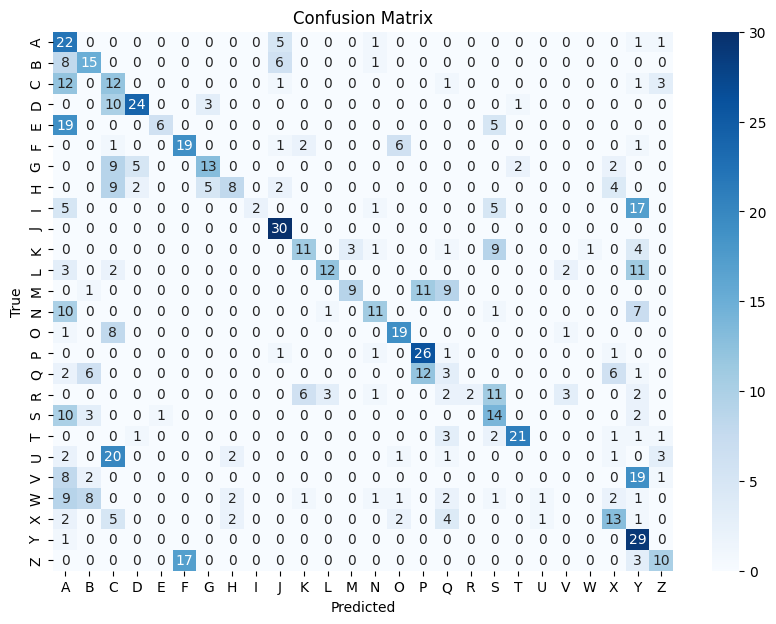

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

# Generate predictions for the new dataset (test data)
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test dataset
y_true = test_generator.classes

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

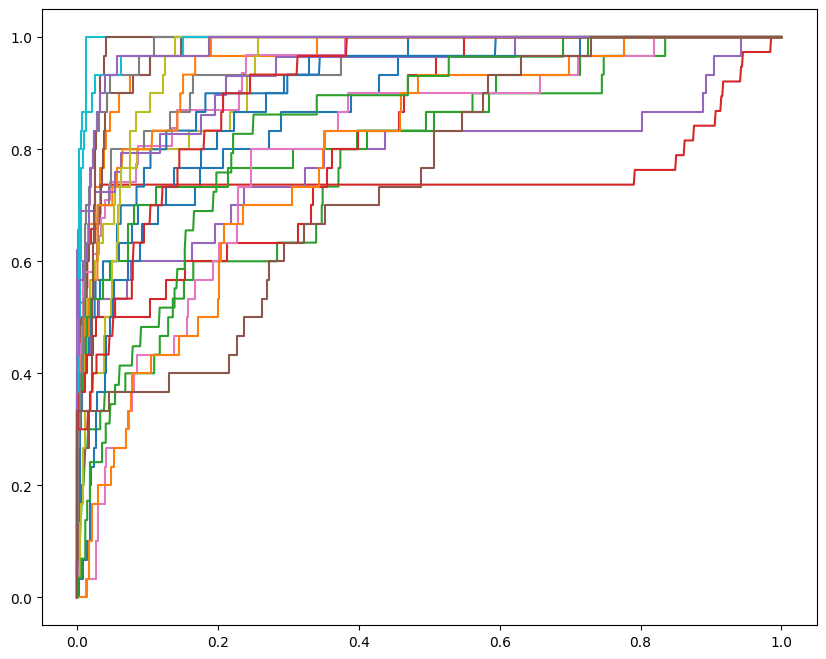

In [ ]:
# Binarize the labels for multi-class classification
y_true_bin = label_binarize(y_true, classes=range(len(test_generator.class_indices)))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

# Get a list of class labels from the dictionary keys
class_labels = list(test_generator.class_indices.keys())

for i, label in enumerate(class_labels):
    # Calculate ROC curve and AUC for each class
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)


    plt.plot(fpr, tpr, label=f'Class {label} (AUC = {roc_auc:.2f})')

<ipython-input-13-c7eab1e51944>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


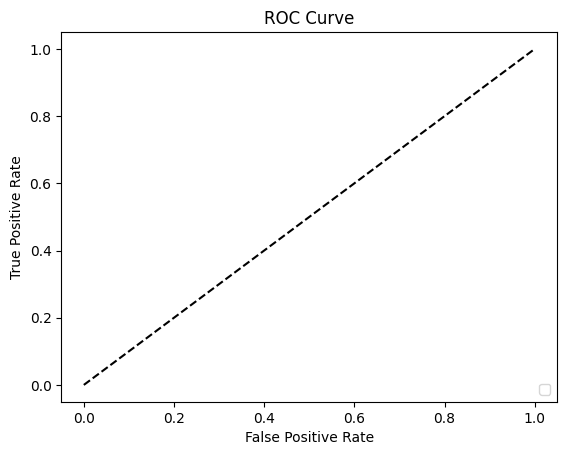

In [ ]:
# Plot random classifier
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

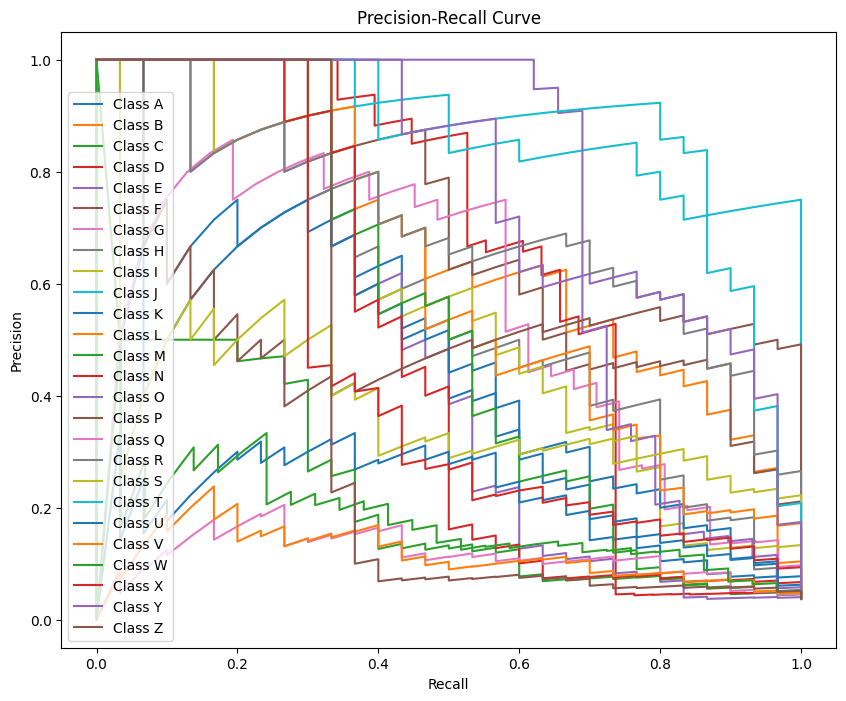

In [ ]:
# Loop through each class and plot Precision-Recall curve
plt.figure(figsize=(10, 8))

# Get a list of class labels
class_labels = list(test_generator.class_indices.keys())

for i, label in enumerate(class_labels):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {label}')  # Use label for plotting

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

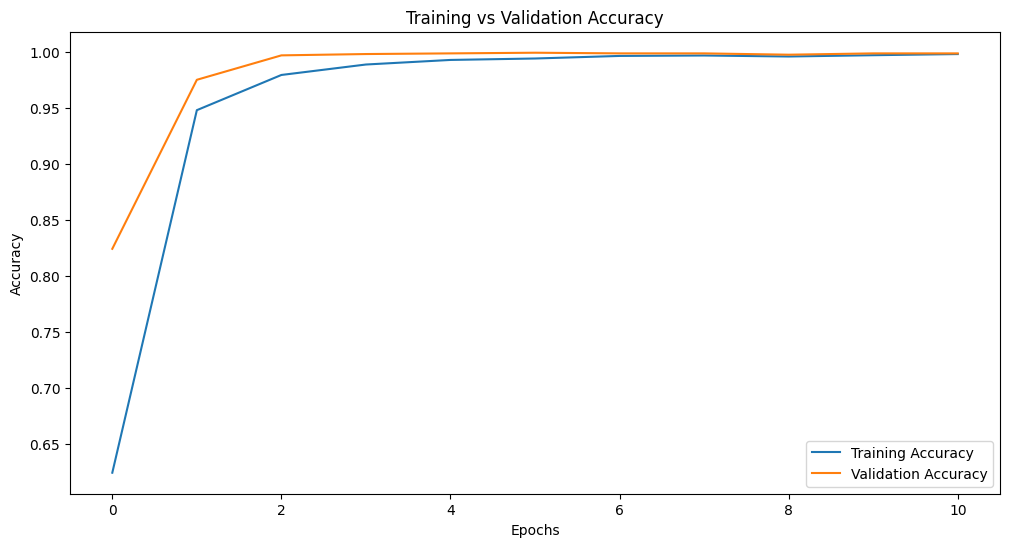

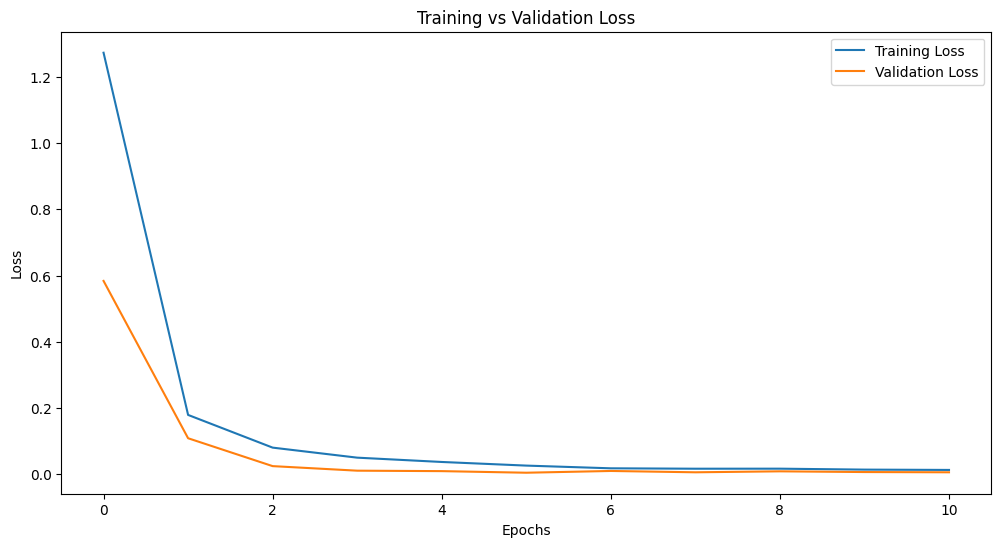

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Testing Different Pre-Trained Models


In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
def build_model_with_base(base_model, num_classes):
    # Set the pre-trained base model,
    for layer in base_model.layers[:-10]:  # Freeze all layers except the last 10
        layer.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)  #  dense layer for fine-tuning
    predictions = layers.Dense(num_classes, activation='softmax')(x)  # Output layer

    # Construct model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
# Load pre-trained models
mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(112, 112, 3))
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(112, 112, 3))
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(112, 112, 3))

# Number of output classes
num_classes = len(class_labels)

# Build models with different base architectures
mobilenet_model = build_model_with_base(mobilenet_base, num_classes)
resnet_model = build_model_with_base(resnet_base, num_classes)
inception_model = build_model_with_base(inception_base, num_classes)


<ipython-input-12-eee1394ea0f1>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(112, 112, 3))


In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
history_mobilenet = mobilenet_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)
history_resnet = resnet_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)
history_inception = inception_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 1967s 4s/step - accuracy: 0.6895 - loss: 1.6926 - val_accuracy: 0.7077 - val_loss: 1.1627
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 383ms/step - accuracy: 0.9316 - loss: 0.2759 - val_accuracy: 0.8014 - val_loss: 0.6471
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 384ms/step - accuracy: 0.9476 - loss: 0.2208 - val_accuracy: 0.8668 - val_loss: 1.0743
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 206s 421ms/step - accuracy: 0.9676 - loss: 0.1432 - val_accuracy: 0.9682 - val_loss: 0.1343
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 189s 385ms/step - accuracy: 0.9642 - loss: 0.1807 - val_accuracy: 0.9918 - val_loss: 0.0377
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 189s 386ms/step - accuracy: 0.9740 - loss: 0.1297 - val_accuracy: 0.9546 - val_loss: 0.3822
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 383ms/step - accuracy: 0.9853 - loss: 0.0901 - val_accuracy: 0.8079 - val_loss: 1.9094
Epoch 8/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 187s 382ms/step - accuracy: 0.9703 - l

In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
# Evaluate each model on the test set without class_weight
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_generator)
test_loss_resnet, test_acc_resnet = resnet_model.evaluate(test_generator)
test_loss_inception, test_acc_inception = inception_model.evaluate(test_generator)

print(f"MobileNetV2 Test Accuracy: {test_acc_mobilenet}")
print(f"ResNet50 Test Accuracy: {test_acc_resnet}")
print(f"InceptionV3 Test Accuracy: {test_acc_inception}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


106/106 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.9986 - loss: 0.0095
106/106 ━━━━━━━━━━━━━━━━━━━━ 85s 805ms/step - accuracy: 0.8816 - loss: 0.3308
106/106 ━━━━━━━━━━━━━━━━━━━━ 47s 447ms/step - accuracy: 0.8959 - loss: 0.4424
MobileNetV2 Test Accuracy: 0.9952802062034607
ResNet50 Test Accuracy: 0.886725664138794
InceptionV3 Test Accuracy: 0.895575225353241


In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
# Generate predictions for the test set
y_pred_mobilenet = mobilenet_model.predict(test_generator)
y_pred_resnet = resnet_model.predict(test_generator)
y_pred_inception = inception_model.predict(test_generator)

# Get predicted classes
y_pred_mobilenet_classes = np.argmax(y_pred_mobilenet, axis=1)
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)
y_pred_inception_classes = np.argmax(y_pred_inception, axis=1)


106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 220ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 90s 831ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 477ms/step


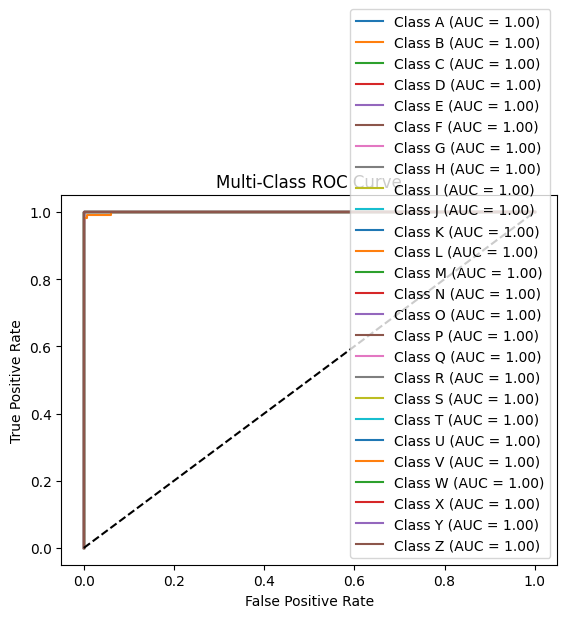

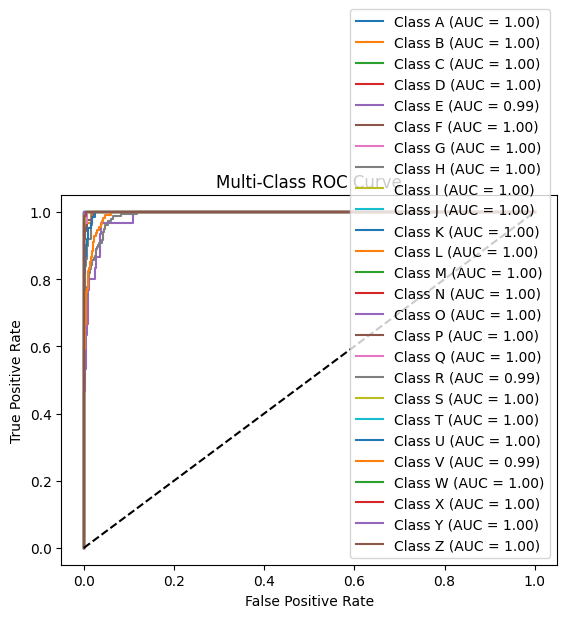

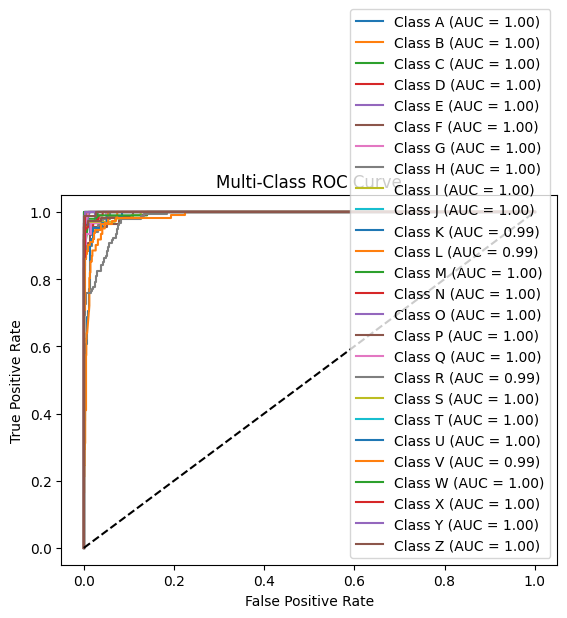

In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
def plot_confusion_matrix(y_true, y_pred, model_name, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_precision_recall_curve_multiclass(y_true, y_pred, class_labels):
    # Loop through each class and plot the precision-recall curve
    for i in range(len(class_labels)):
        precision, recall, _ = precision_recall_curve(y_true == i, y_pred[:, i])
        plt.plot(recall, precision, label=f'Class {class_labels[i]}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Multiclass Precision-Recall Curve')
    plt.legend()
    plt.show()



def plot_multi_class_roc_curve(y_true, y_pred, class_labels):
    # Binarize the labels for multi-class ROC curve
    y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

    # Loop through each class and compute ROC curve and AUC
    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


plot_multi_class_roc_curve(test_generator.classes, y_pred_mobilenet, class_labels)
plot_multi_class_roc_curve(test_generator.classes, y_pred_resnet, class_labels)
plot_multi_class_roc_curve(test_generator.classes, y_pred_inception, class_labels)


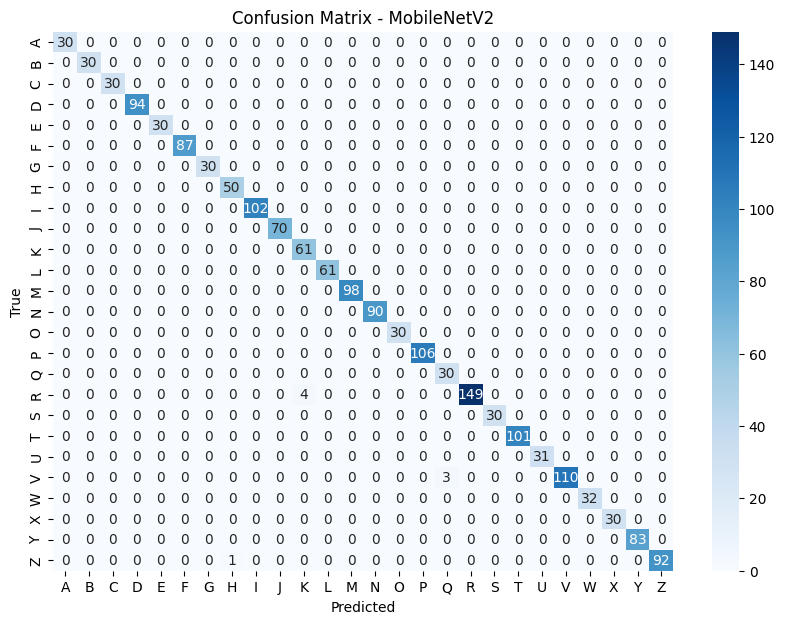

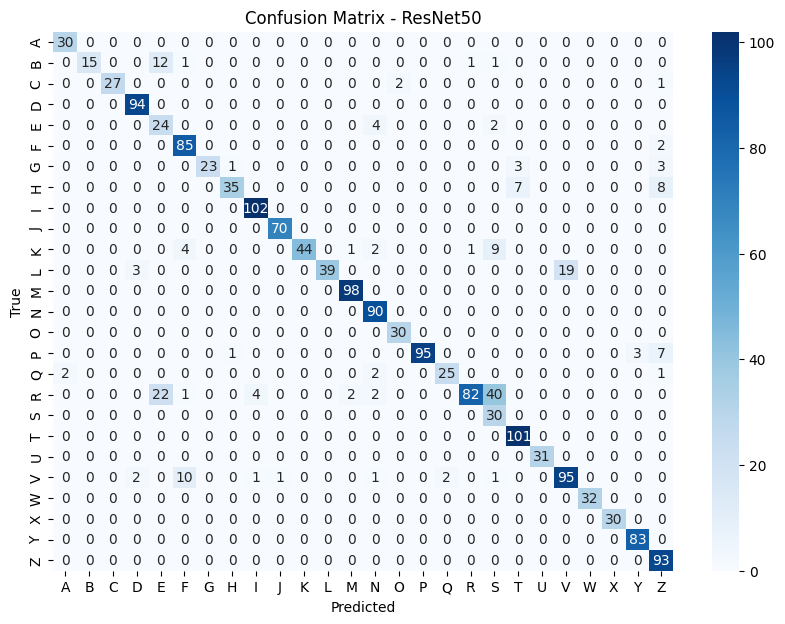

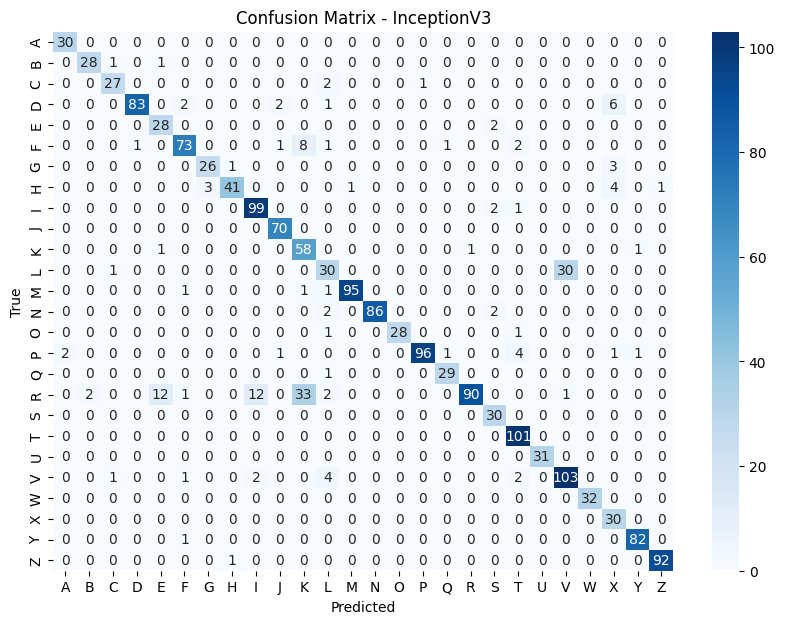

In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
plot_confusion_matrix(test_generator.classes, y_pred_mobilenet_classes, 'MobileNetV2', class_labels)
plot_confusion_matrix(test_generator.classes, y_pred_resnet_classes, 'ResNet50', class_labels)
plot_confusion_matrix(test_generator.classes, y_pred_inception_classes, 'InceptionV3', class_labels)


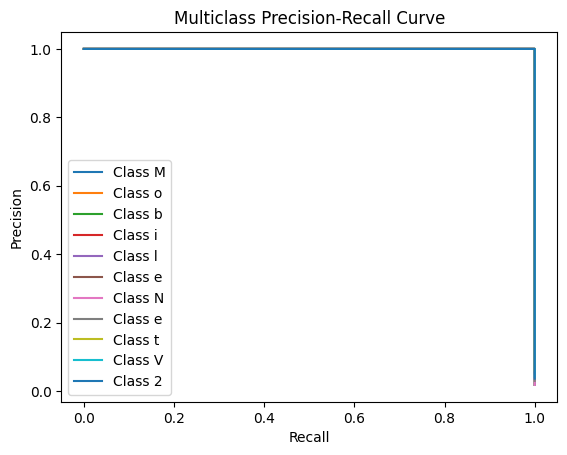

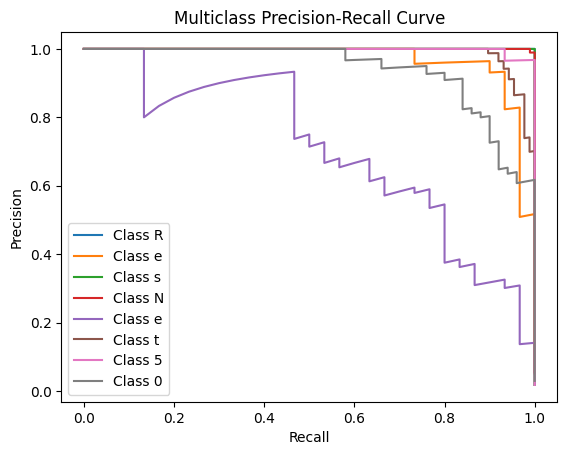

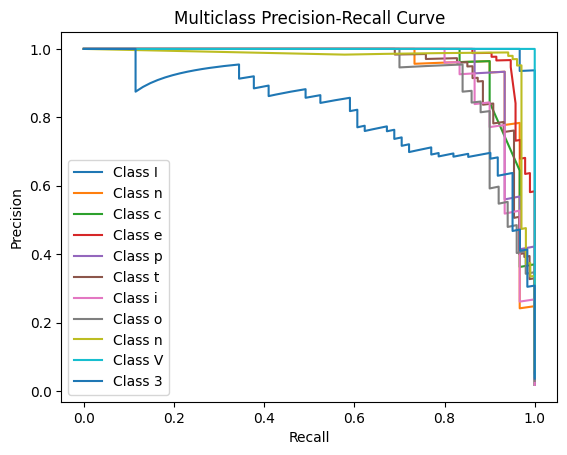

In [ ]:
#FOR TESTING DIFFERENT PRE-TRAINED MODELS.
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_mobilenet, 'MobileNetV2')
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_resnet, 'ResNet50')
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_inception, 'InceptionV3')

#Testing Different Optimizers Using MobileNetV2

In [ ]:
#FOR TESTING DIFFERENT OPTIMIZERS USING MOBILENETV2
optimizers =[
    Adam(learning_rate=0.0001),
    SGD(learning_rate=0.01, momentum=0.9),
    Adagrad(learning_rate=0.01),
    Adadelta(learning_rate=1.0),
    RMSprop(learning_rate=0.001)
]

history_dict = {}  #store training histories

# Train the model with each optimizer
for optimizer in optimizers:
    print(f"Training with optimizer: {optimizer.__class__.__name__}")

    model = build_model(optimizer)

    # Train the model
    history = model.fit(train_generator, epochs=10, validation_data=val_generator)

    # Store history for plotting
    history_dict[optimizer.__class__.__name__] = history


Training with optimizer: Adam


<ipython-input-3-b7629c88674f>:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(112, 112, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 1888s 4s/step - accuracy: 0.6511 - loss: 1.4328 - val_accuracy: 0.9741 - val_loss: 0.1215
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 116s 236ms/step - accuracy: 0.9827 - loss: 0.0902 - val_accuracy: 0.9870 - val_loss: 0.0590
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 115s 236ms/step - accuracy: 0.9974 - loss: 0.0372 - val_accuracy: 0.9935 - val_loss: 0.0325
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 117s 239ms/step - accuracy: 0.9979 - loss: 0.0215 - val_accuracy: 0.9929 - val_loss: 0.0270
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 138s 231ms/step - accuracy: 0.9993 - loss: 0.0133 - val_accuracy: 0.9923 - val_loss: 0.0224
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 173s 295ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.9953 - val_loss: 0.0214
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 144s 294ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9947 - val_loss: 0.0166
Epoch 8/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 115s 235ms/step - accuracy: 1.0000 - l

In [ ]:
#FOR TESTING DIFFERENT OPTIMIZERS USING MOBILENETV2
def build_model(optimizer):
    # Load MobileNet without the top layers
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(112, 112, 3))

    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

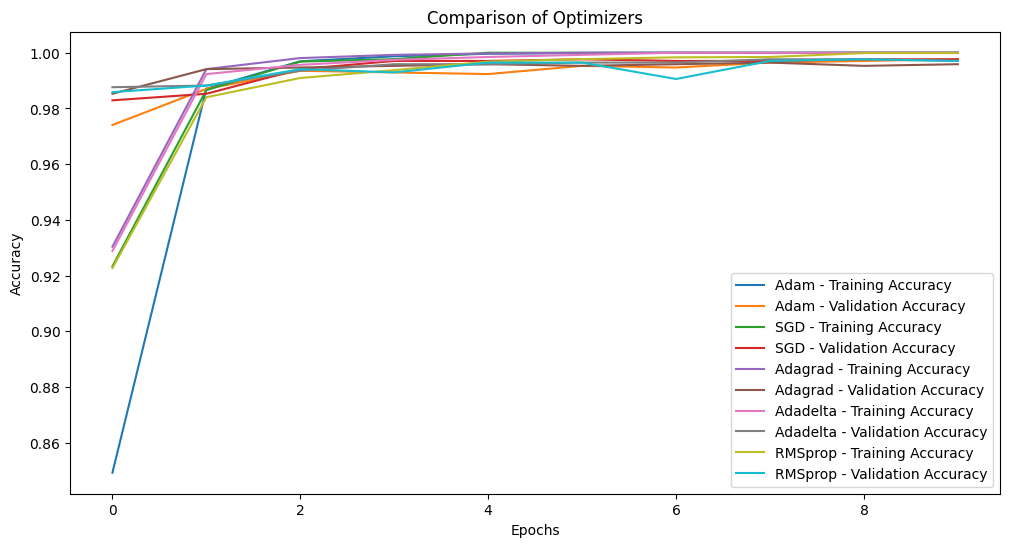

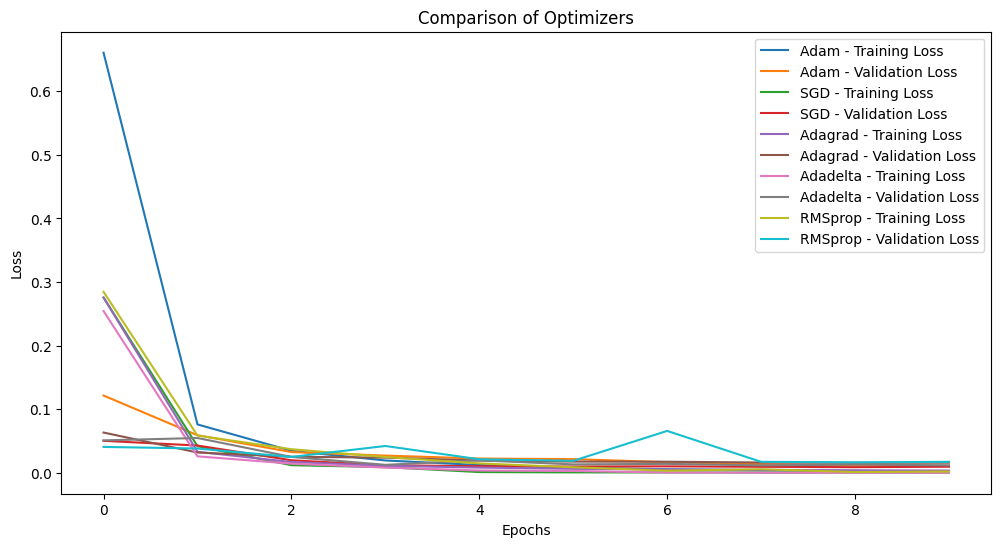

In [ ]:
# FOR TESTING DIFFERENT OPTIMIZERS USING MOBILENETV2
# Plot the results for each optimizer
plt.figure(figsize=(12, 6))

# Plot the training and validation accuracy for each optimizer
for optimizer_name, history in history_dict.items():
    # Get the final training and validation accuracy for this optimizer
    train_accuracy = history.history['accuracy'][-1]  # Final training accuracy
    val_accuracy = history.history['val_accuracy'][-1]  # Final validation accuracy

    # Plot the accuracy
    plt.plot(history.history['accuracy'], label=f'{optimizer_name} - Train Accuracy: {train_accuracy:.4f}')
    plt.plot(history.history['val_accuracy'], label=f'{optimizer_name} - Val Accuracy: {val_accuracy:.4f}')

plt.title('Comparison of Optimizers - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plot the training and validation loss for each optimizer
plt.figure(figsize=(12, 6))

for optimizer_name, history in history_dict.items():
    # Get the final training and validation loss for this optimizer
    train_loss = history.history['loss'][-1]  # Final training loss
    val_loss = history.history['val_loss'][-1]  # Final validation loss

    # Plot the loss
    plt.plot(history.history['loss'], label=f'{optimizer_name} - Train Loss: {train_loss:.4f}')
    plt.plot(history.history['val_loss'], label=f'{optimizer_name} - Val Loss: {val_loss:.4f}')

plt.title('Comparison of Optimizers - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


#Testing Different Image Sizes and Batch Sizes

In [ ]:
def build_model(image_size):
    # Load the pre-trained MobileNetV2 model without the top layers
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))


    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with Adam optimizer
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
#  image sizes and batch sizes to test
image_sizes = [(112, 112), (56, 56), (224, 224)]
batch_sizes = [4, 8, 16]


train_dir = '/content/drive/MyDrive/ASL Dataset/split/trainsplit'
val_dir = '/content/drive/MyDrive/ASL Dataset/split/validation'

# Loop over image sizes and batch sizes
for image_size in image_sizes:
    for batch_size in batch_sizes:
        print(f"Training with image size {image_size} and batch size {batch_size}")


        train_datagen = ImageDataGenerator(rescale=1./255)
        val_datagen = ImageDataGenerator(rescale=1./255)


        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical'
        )

        val_generator = val_datagen.flow_from_directory(
            val_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical'
        )

        y_true = train_generator.classes
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_true),
            y=y_true
        )
        class_weights_dict = dict(enumerate(class_weights))

        print("Class Weights:", class_weights_dict)

        # Build the model
        model = build_model(image_size)



        # Train the model
        history = model.fit(
            train_generator,
            epochs=3,
            validation_data=val_generator,
            class_weight=class_weights_dict,
            verbose=1
        )

Training with image size (112, 112) and batch size 4
Found 7828 images belonging to 26 classes.
Found 1697 images belonging to 26 classes.
Class Weights: {0: np.float64(2.1505494505494505), 1: np.float64(2.1505494505494505), 2: np.float64(2.1505494505494505), 3: np.float64(0.692130857648099), 4: np.float64(2.1505494505494505), 5: np.float64(0.7470891391486925), 6: np.float64(2.1505494505494505), 7: np.float64(1.2977453580901857), 8: np.float64(0.6378748370273793), 9: np.float64(0.9321266968325792), 10: np.float64(1.0676486633933442), 11: np.float64(1.0676486633933442), 12: np.float64(0.7185606756012484), 13: np.float64(0.7168498168498169), 14: np.float64(2.1505494505494505), 15: np.float64(0.6144427001569859), 16: np.float64(2.1505494505494505), 17: np.float64(0.42345558801255), 18: np.float64(2.1505494505494505), 19: np.float64(0.6419550598655076), 20: np.float64(2.1352973267866884), 21: np.float64(0.5723895875987131), 22: np.float64(2.0481423338566196), 23: np.float64(2.1505494505494

<ipython-input-5-7572907be5df>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
1957/1957 ━━━━━━━━━━━━━━━━━━━━ 4321s 2s/step - accuracy: 0.8491 - loss: 0.5914 - val_accuracy: 0.9582 - val_loss: 0.1210
Epoch 2/3
1957/1957 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9808 - loss: 0.0678 - val_accuracy: 0.9334 - val_loss: 0.3216
Epoch 3/3
1957/1957 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.9833 - loss: 0.0618 - val_accuracy: 0.9876 - val_loss: 0.0468
Training with image size (112, 112) and batch size 8
Found 7828 images belonging to 26 classes.
Found 1697 images belonging to 26 classes.
Class Weights: {0: np.float64(2.1505494505494505), 1: np.float64(2.1505494505494505), 2: np.float64(2.1505494505494505), 3: np.float64(0.692130857648099), 4: np.float64(2.1505494505494505), 5: np.float64(0.7470891391486925), 6: np.float64(2.1505494505494505), 7: np.float64(1.2977453580901857), 8: np.float64(0.6378748370273793), 9: np.float64(0.9321266968325792), 10: np.float64(1.0676486633933442), 11: np.float64(1.0676486633933442), 12: np.float64(0.71856067560124

...

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
979/979 ━━━━━━━━━━━━━━━━━━━━ 79s 70ms/step - accuracy: 0.8324 - loss: 0.7135 - val_accuracy: 0.9864 - val_loss: 0.0599
Epoch 2/3
979/979 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.9923 - loss: 0.0302 - val_accuracy: 0.9835 - val_loss: 0.0605
Epoch 3/3
979/979 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.9945 - loss: 0.0280 - val_accuracy: 0.9859 - val_loss: 0.0408
Training with image size (224, 224) and batch size 16
Found 7828 images belonging to 26 classes.
Found 1697 images belonging to 26 classes.
Class Weights: {0: np.float64(2.1505494505494505), 1: np.float64(2.1505494505494505), 2: np.float64(2.1505494505494505), 3: np.float64(0.692130857648099), 4: np.float64(2.1505494505494505), 5: np.float64(0.7470891391486925), 6: np.float64(2.1505494505494505), 7: np.float64(1.2977453580901857), 8: np.float64(0.6378748370273793), 9: np.float64(0.9321266968325792), 10: np.float64(1.0676486633933442), 11: np.float64(1.0676486633933442), 12: np.float64(0.7185606756012484), 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
490/490 ━━━━━━━━━━━━━━━━━━━━ 67s 116ms/step - accuracy: 0.8398 - loss: 0.6612 - val_accuracy: 0.9446 - val_loss: 0.1891
Epoch 2/3
490/490 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.9925 - loss: 0.0340 - val_accuracy: 0.9959 - val_loss: 0.0194
Epoch 3/3
490/490 ━━━━━━━━━━━━━━━━━━━━ 47s 97ms/step - accuracy: 0.9993 - loss: 0.0048 - val_accuracy: 0.9965 - val_loss: 0.0183


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (9, 7) + inhomogeneous part.

#Testing Using Batch Normalization In Training

In [ ]:
def build_model_with_bn(image_size):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))


    for layer in base_model.layers:
        layer.trainable = False


    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)  # Batch Normalization after pooling
    x = layers.Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)  # Batch Normalization after dense layer
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with Adam optimizer
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
# Without Batch Normalization
def build_model_without_bn(image_size):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Train both models
history_with_bn = build_model_with_bn(image_size=(56, 56)).fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    verbose=1
)

history_without_bn = build_model_without_bn(image_size=(56, 56)).fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    verbose=1
)


<ipython-input-10-4db4ce01b8ef>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 1592s 405ms/step - accuracy: 0.3105 - loss: 2.5268 - val_accuracy: 0.8038 - val_loss: 0.9240
Epoch 2/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 128s 33ms/step - accuracy: 0.7016 - loss: 1.0554 - val_accuracy: 0.8698 - val_loss: 0.6006
Epoch 3/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 128s 33ms/step - accuracy: 0.7665 - loss: 0.8368 - val_accuracy: 0.8969 - val_loss: 0.5974
Epoch 4/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 139s 32ms/step - accuracy: 0.8149 - loss: 0.6780 - val_accuracy: 0.9216 - val_loss: 0.3881
Epoch 5/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 144s 33ms/step - accuracy: 0.8275 - loss: 0.6257 - val_accuracy: 0.9258 - val_loss: 0.3819


<ipython-input-14-5c0d86c48e4f>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))


Epoch 1/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 129s 31ms/step - accuracy: 0.6544 - loss: 1.3734 - val_accuracy: 0.9387 - val_loss: 0.2402
Epoch 2/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 123s 32ms/step - accuracy: 0.9478 - loss: 0.1801 - val_accuracy: 0.9364 - val_loss: 0.2506
Epoch 3/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 122s 31ms/step - accuracy: 0.9801 - loss: 0.0815 - val_accuracy: 0.9617 - val_loss: 0.1405
Epoch 4/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 125s 32ms/step - accuracy: 0.9870 - loss: 0.0464 - val_accuracy: 0.9776 - val_loss: 0.0857
Epoch 5/5
3914/3914 ━━━━━━━━━━━━━━━━━━━━ 139s 31ms/step - accuracy: 0.9933 - loss: 0.0260 - val_accuracy: 0.9800 - val_loss: 0.0823


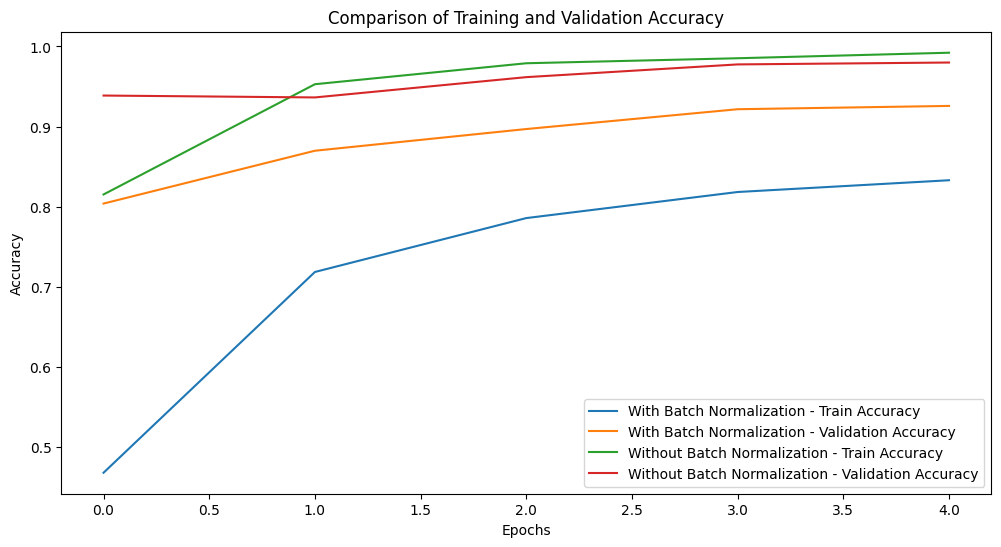

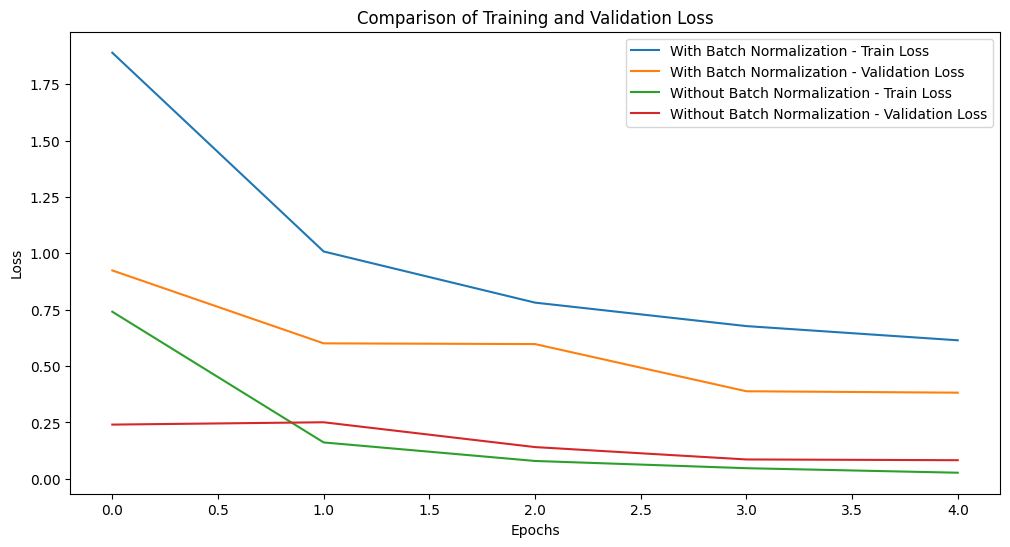

In [ ]:
# Plot training and validation accuracy for both models
plt.figure(figsize=(12, 6))

# With Batch Normalization
plt.plot(history_with_bn.history['accuracy'], label='With Batch Normalization - Train Accuracy')
plt.plot(history_with_bn.history['val_accuracy'], label='With Batch Normalization - Validation Accuracy')

# Without Batch Normalization
plt.plot(history_without_bn.history['accuracy'], label='Without Batch Normalization - Train Accuracy')
plt.plot(history_without_bn.history['val_accuracy'], label='Without Batch Normalization - Validation Accuracy')

plt.title('Comparison of Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plot training and validation loss for both models
plt.figure(figsize=(12, 6))

# With Batch Normalization
plt.plot(history_with_bn.history['loss'], label='With Batch Normalization - Train Loss')
plt.plot(history_with_bn.history['val_loss'], label='With Batch Normalization - Validation Loss')

# Without Batch Normalization
plt.plot(history_without_bn.history['loss'], label='Without Batch Normalization - Train Loss')
plt.plot(history_without_bn.history['val_loss'], label='Without Batch Normalization - Validation Loss')

plt.title('Comparison of Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


# Training Final Model

Normalising The images

In [ ]:

train_dir = '/content/drive/MyDrive/ASL Dataset/split/trainsplit'
val_dir = '/content/drive/MyDrive/ASL Dataset/split/validation'
test_dir = '/content/drive/MyDrive/ASL Dataset/split/test'

# Image size and batch size
image_size = (224, 224)
batch_size = 64

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Validation generator
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Test generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Handling class imbalance
class_labels = list(train_generator.class_indices.keys())
y_true = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true),
    y=y_true
)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

Found 7828 images belonging to 26 classes.
Found 1698 images belonging to 26 classes.
Found 1695 images belonging to 26 classes.
Class Weights: {0: np.float64(2.1505494505494505), 1: np.float64(2.1505494505494505), 2: np.float64(2.1505494505494505), 3: np.float64(0.692130857648099), 4: np.float64(2.1505494505494505), 5: np.float64(0.7470891391486925), 6: np.float64(2.1505494505494505), 7: np.float64(1.2977453580901857), 8: np.float64(0.6378748370273793), 9: np.float64(0.9321266968325792), 10: np.float64(1.0676486633933442), 11: np.float64(1.0676486633933442), 12: np.float64(0.7185606756012484), 13: np.float64(0.7168498168498169), 14: np.float64(2.1505494505494505), 15: np.float64(0.6144427001569859), 16: np.float64(2.1505494505494505), 17: np.float64(0.42345558801255), 18: np.float64(2.1505494505494505), 19: np.float64(0.6419550598655076), 20: np.float64(2.1352973267866884), 21: np.float64(0.5723895875987131), 22: np.float64(2.0481423338566196), 23: np.float64(2.1505494505494505), 24: 

In [ ]:
 base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
 base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
def build_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256)(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = build_model()

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

history_mobilenet = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],  # Added LR reduction
    verbose=1
)


<ipython-input-4-3d67660a09ed>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(512, 512, 3))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


# Evaluating And Deploying The Final Model

In [ ]:

y_test_probs = model.predict(test_generator)
y_test_pred = np.argmax(y_test_probs, axis=1)
y_test_true = test_generator.classes

# Compute F1 score
f1_test = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"Test F1 Score: {f1_test:.2f}")

# Plot confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_normalized = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_test_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys(),
    cbar=True
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix on Test Set')
plt.xticks(rotation=45)
plt.show()

# Printing validation accuracy
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy:.4f}")


In [ ]:
save_path = "/content/drive/My Drive/model_final_test.h5"
model.save(save_path)